In [3]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [5]:
df = pd.read_excel("/content/drive/MyDrive/PROJECT/AAPL.xlsx")

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 184 entries, 0 to 183
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   Date       184 non-null    datetime64[ns]
 1   Open       184 non-null    float64       
 2   High       184 non-null    float64       
 3   Low        184 non-null    float64       
 4   Close      184 non-null    float64       
 5   Adj Close  184 non-null    float64       
 6   Volume     184 non-null    int64         
dtypes: datetime64[ns](1), float64(5), int64(1)
memory usage: 10.2 KB


In [7]:
df.head()

,Date,Open,High,Low,Close,Adj Close,Volume
0,2014-09-29,100.589996,100.690002,98.040001,99.620003,93.514290,142718700
1,2014-10-06,99.949997,102.379997,98.309998,100.730003,94.556244,280258200
2,2014-10-13,101.330002,101.779999,95.180000,97.669998,91.683792,358539800
3,2014-10-20,98.320000,105.489998,98.220001,105.220001,98.771042,358532900
4,2014-10-27,104.849998,108.040001,104.699997,108.000000,101.380676,220230600


In [8]:
df.tail()

,Date,Open,High,Low,Close,Adj Close,Volume
179,2018-03-05,175.210007,180.000000,174.270004,179.979996,179.979996,139852700
180,2018-03-12,180.289993,183.500000,177.619995,178.020004,178.020004,155417500
181,2018-03-19,177.320007,177.470001,164.940002,164.940002,164.940002,172670700
182,2018-03-26,168.070007,175.149994,165.190002,167.779999,167.779999,157898400
183,2018-03-29,167.804993,171.750000,166.899994,167.779999,167.779999,38398505


In [9]:
df.isnull()

,Date,Open,High,Low,Close,Adj Close,Volume
0,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...
179,False,False,False,False,False,False,False
180,False,False,False,False,False,False,False
181,False,False,False,False,False,False,False
182,False,False,False,False,False,False,False


In [10]:
df['MA20'] = df['Close'].rolling(window=20).mean()
df['MA50'] = df['Close'].rolling(window=50).mean()

print(df[['Date', 'Close', 'MA20', 'MA50']].tail())

          Date       Close        MA20      MA50
179 2018-03-05  179.979996  171.852999  159.6218
180 2018-03-12  178.020004  172.601499  160.3090
181 2018-03-19  164.940002  172.223499  160.7410
182 2018-03-26  167.779999  171.878999  161.2756
183 2018-03-29  167.779999  171.760500  161.7858


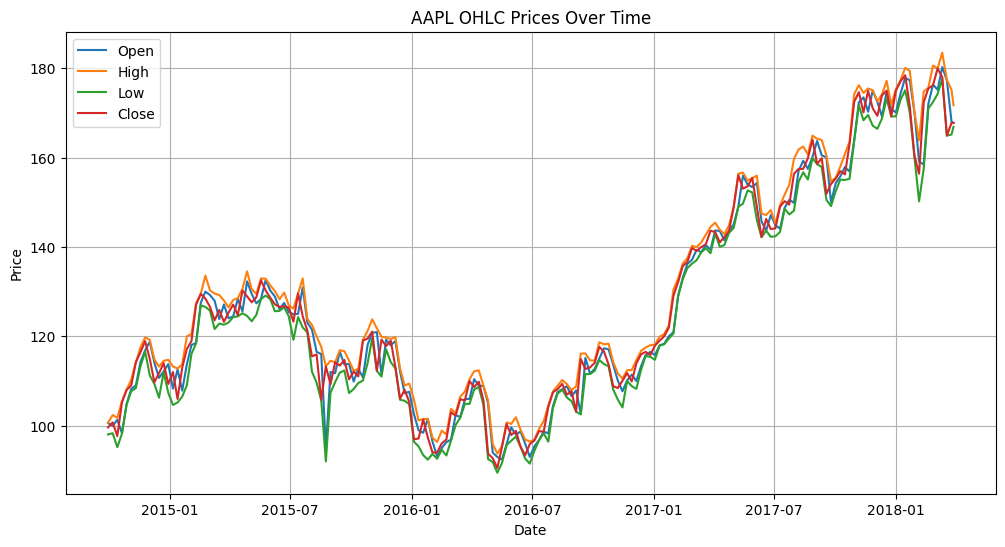

In [11]:
plt.figure(figsize=(12,6))

plt.plot(df['Date'], df['Open'], label='Open')
plt.plot(df['Date'], df['High'], label='High')
plt.plot(df['Date'], df['Low'], label='Low')
plt.plot(df['Date'], df['Close'], label='Close')

plt.title('AAPL OHLC Prices Over Time')
plt.xlabel('Date')
plt.ylabel('Price')
plt.legend()
plt.grid(True)
plt.show()

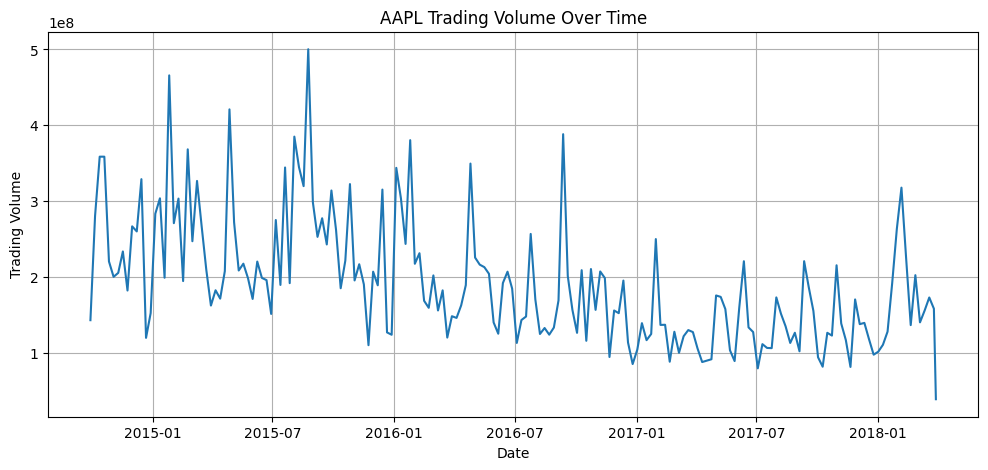

In [12]:
plt.figure(figsize=(12,5))

plt.plot(df['Date'], df['Volume'])

plt.title('AAPL Trading Volume Over Time')
plt.xlabel('Date')
plt.ylabel('Trading Volume')
plt.grid(True)
plt.show()

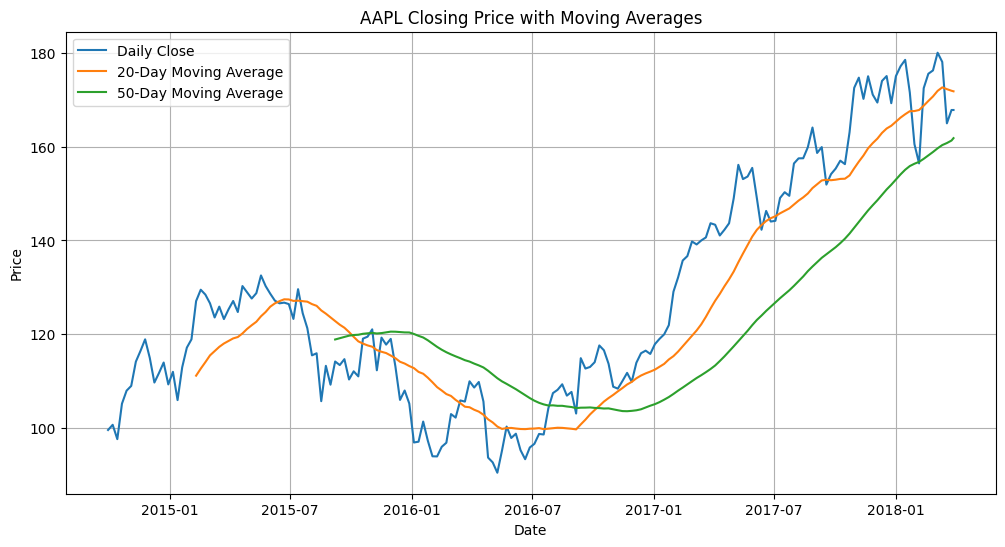

In [15]:
plt.figure(figsize=(12,6))

plt.plot(df['Date'], df['Close'], label='Daily Close')
plt.plot(df['Date'], df['MA20'], label='20-Day Moving Average')
plt.plot(df['Date'], df['MA50'], label='50-Day Moving Average')

plt.title('AAPL Closing Price with Moving Averages')
plt.xlabel('Date')
plt.ylabel('Price')
plt.legend()
plt.grid(True)
plt.show()

In [16]:
df['Returns'] = df['Close'].pct_change()

print(df[['Date', 'Close', 'Returns']].head(10))

        Date       Close   Returns
0 2014-09-29   99.620003       NaN
1 2014-10-06  100.730003  0.011142
2 2014-10-13   97.669998 -0.030378
3 2014-10-20  105.220001  0.077301
4 2014-10-27  108.000000  0.026421
5 2014-11-03  109.010002  0.009352
6 2014-11-10  114.180000  0.047427
7 2014-11-17  116.470001  0.020056
8 2014-11-24  118.930000  0.021121
9 2014-12-01  115.000000 -0.033045


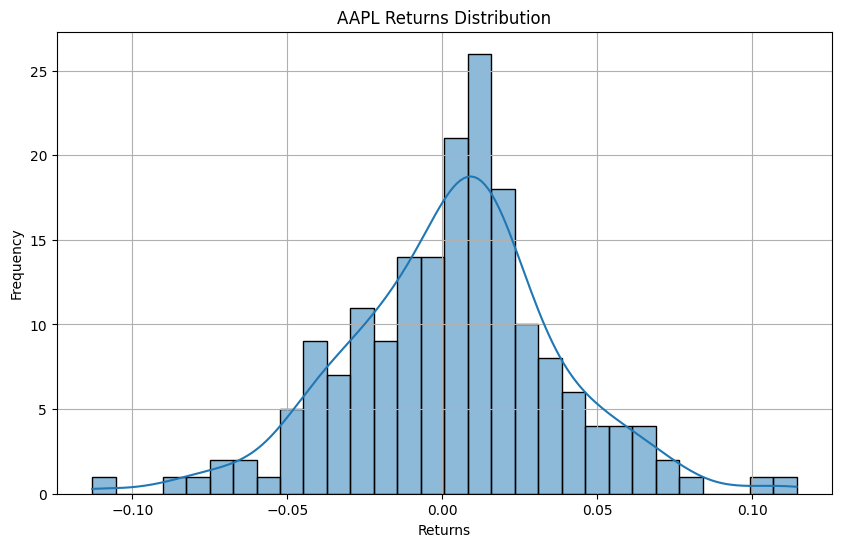

In [18]:
import seaborn as sns
plt.figure(figsize=(10,6))

sns.histplot(
    df['Returns'].dropna(),
    kde=True,
    bins=30
)

plt.title('AAPL Returns Distribution')
plt.xlabel('Returns')
plt.ylabel('Frequency')
plt.grid(True)
plt.show()